In [1]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

shutil.copytree(
    '/content/drive/MyDrive/FaceDetection/data',
    '/content/data',
    dirs_exist_ok=True
)

shutil.copytree(
    '/content/drive/MyDrive/FaceDetection/aug_data',
    '/content/aug_data',
    dirs_exist_ok=True
)

print("Done!")
print("data:", os.path.exists('/content/data'))
print("aug_data:", os.path.exists('/content/aug_data'))

Mounted at /content/drive
Done!
data: True
aug_data: True


In [2]:
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uuid
import cv2

In [3]:
IMAGES_PATH = os.path.join('data', 'images')
number_images = 30

In [8]:
from google.colab.output import eval_js
from IPython.display import display, Javascript
import base64
display(Javascript("""
async function collectImages(numberImages) {
    const video = document.createElement('video');
    const stream = await navigator.mediaDevices.getUserMedia({
        video: true
    });

    video.srcObject = stream;
    video.setAttribute('playsinline', '');
    video.style.width = '500px';
    document.body.appendChild(video);
    await video.play();
    const canvas = document.createElement('canvas');
    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    let images = [];
    for (let i = 0; i < numberImages; i++) {
        const context = canvas.getContext('2d');
        context.drawImage(video, 0, 0);
        images.push(canvas.toDataURL('image/jpeg', 0.8));
        await new Promise(resolve => setTimeout(resolve, 500));
    }

    stream.getTracks().forEach(track => track.stop());
    video.remove();

    return images;
}
"""))

images = eval_js(f"collectImages({number_images})")

for imgnum, image in enumerate(images):
    print('Collecting image{}'.format(imgnum))

    binary = base64.b64decode(image.split(',')[1])

    frame = cv2.imdecode(
        np.frombuffer(binary, dtype=np.uint8),
        cv2.IMREAD_COLOR
    )

    imgname = os.path.join(
        IMAGES_PATH,
        f'{str(uuid.uuid1())}.jpg'
    )

    cv2.imwrite(imgname, frame)

    time.sleep(0.5)

print("Done!")

<IPython.core.display.Javascript object>

Done!


Reviewing dataset and building iamge loading function


In [3]:
import tensorflow as tf
import json

In [4]:

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

In [11]:
images.as_numpy_iterator().next()

b'data/images/10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.jpg'

In [6]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img, channels=3)
    return img

In [111]:
images = images.map(load_image)

NameError: name 'images' is not defined

array([[[215, 222, 232],
        [216, 223, 233],
        [216, 223, 233],
        ...,
        [204, 205, 209],
        [201, 202, 206],
        [200, 201, 205]],

       [[217, 224, 234],
        [217, 224, 234],
        [217, 224, 234],
        ...,
        [204, 205, 209],
        [202, 203, 207],
        [201, 202, 206]],

       [[218, 225, 235],
        [218, 225, 235],
        [217, 224, 234],
        ...,
        [203, 204, 208],
        [203, 204, 208],
        [203, 204, 208]],

       ...,

       [[ 75,  74,  88],
        [ 77,  76,  90],
        [ 83,  83,  95],
        ...,
        [106,  79,  88],
        [107,  80,  89],
        [110,  83,  92]],

       [[ 87,  85,  99],
        [ 93,  91, 105],
        [103, 101, 114],
        ...,
        [107,  79,  91],
        [109,  81,  93],
        [114,  86,  98]],

       [[ 88,  86, 100],
        [ 99,  97, 111],
        [112, 110, 123],
        ...,
        [109,  81,  93],
        [113,  85,  97],
        [119,  91, 103]]], dtype=uint8)
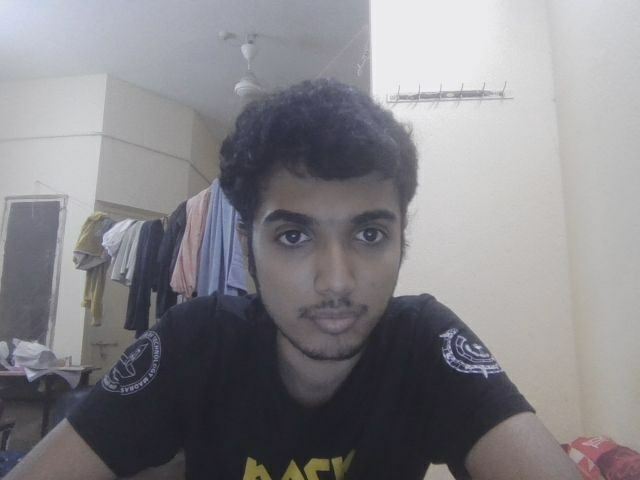

In [14]:
images.as_numpy_iterator().next()

In [15]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

In [16]:
image_generator = images.batch(4).as_numpy_iterator()#gives images in batch of 4

In [19]:
plot_images = image_generator.next()

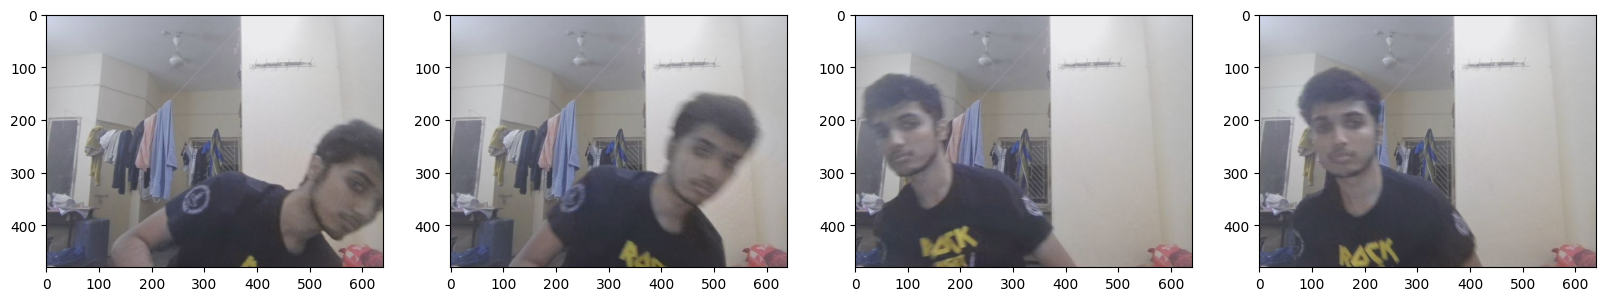

In [20]:
fig, ax = plt.subplots(ncols=4, figsize =(20,20))
for idx, image in enumerate(plot_images):
  ax[idx].imshow(image)

plt.show()


In [30]:
for folder in ['train', 'test', 'val']:
  for file in os.listdir(os.path.join('data', folder, 'images')):

    filename = file.split('.')[0] + '.json'
    existing_filepath = os.path.join('data', 'labels', filename)
    if os.path.exists(existing_filepath):
      new_filepath = os.path.join('data', folder, 'labels', filename)
      os.replace(existing_filepath, new_filepath)

In [7]:
img = cv2.imread(os.path.join('data', 'train', 'images', '/content/data/train/images/10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.jpg'))

In [8]:
img.shape

(480, 640, 3)

In [9]:
import albumentations as alb

In [10]:
augmentor = alb.Compose([alb.RandomCrop(width=450, height = 450),
                         alb.HorizontalFlip(p=0.5),
                         alb.RandomBrightnessContrast(p=0.2),
                         alb.RandomGamma(p=0.2),
                         alb.RGBShift(p=0.2),
                         alb.VerticalFlip(p=0.5)],
                        bbox_params = alb.BboxParams(format='albumentations', label_fields=['class_labels']))

In [11]:
img = cv2.imread(os.path.join('data', 'train', 'images', '10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.jpg'))

array([[[233, 223, 216],
        [233, 223, 216],
        [233, 223, 216],
        ...,
        [209, 205, 204],
        [207, 203, 202],
        [206, 202, 201]],

       [[234, 224, 217],
        [234, 224, 217],
        [234, 224, 217],
        ...,
        [209, 205, 204],
        [208, 204, 203],
        [207, 203, 202]],

       [[235, 225, 218],
        [235, 225, 218],
        [235, 225, 218],
        ...,
        [209, 205, 204],
        [208, 204, 203],
        [208, 204, 203]],

       ...,

       [[ 89,  75,  77],
        [ 91,  77,  79],
        [ 97,  83,  85],
        ...,
        [ 91,  79, 109],
        [ 91,  79, 109],
        [ 94,  82, 112]],

       [[ 99,  85,  87],
        [106,  92,  94],
        [114, 101, 103],
        ...,
        [ 92,  80, 110],
        [ 94,  82, 112],
        [ 98,  86, 116]],

       [[101,  87,  89],
        [112,  98, 100],
        [123, 110, 112],
        ...,
        [ 93,  81, 111],
        [ 98,  86, 116],
        [104,  92, 122]]], dtype=uint8)
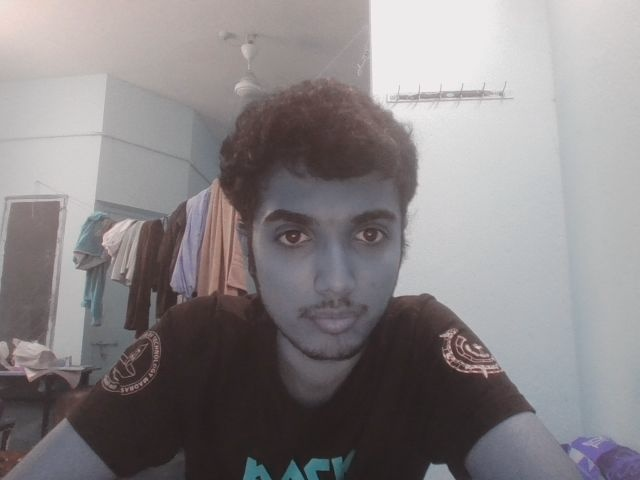

In [12]:
img

In [13]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

# Copy data to Colab content
shutil.copytree(
    '/content/drive/MyDrive/FaceDetection/data',
    '/content/data',
    dirs_exist_ok=True
)

# Copy augmented data to Colab content
shutil.copytree(
    '/content/drive/MyDrive/FaceDetection/aug_data',
    '/content/aug_data',
    dirs_exist_ok=True
)

print("Done!")
print("data:", os.path.exists('/content/data'))
print("aug_data:", os.path.exists('/content/aug_data'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done!
data: True
aug_data: True


In [14]:
data_path = '/content/data'
aug_data_path = '/content/aug_data'

In [19]:
import os
import shutil

base = '/content/drive/MyDrive/FaceDetection/data'

for partition in ['train', 'test', 'val']:
    image_dir = os.path.join(base, partition, 'images')
    label_dir = os.path.join(base, partition, 'labels')

    os.makedirs(label_dir, exist_ok=True)

    copied = 0
    missing = 0

    for image in os.listdir(image_dir):
        name = os.path.splitext(image)[0]
        source_label = os.path.join(base, 'labels', name + '.json')
        destination_label = os.path.join(label_dir, name + '.json')

        if os.path.exists(source_label):
            shutil.copy2(source_label, destination_label)
            copied += 1
        else:
            missing += 1

    print(f'{partition}: {copied} labels copied, {missing} missing')

train: 55 labels copied, 8 missing
test: 13 labels copied, 1 missing
val: 12 labels copied, 1 missing


In [13]:
with open(os.path.join('data', 'train', 'labels', '10d0cfe0-ab8e-11f1-b33a-0242ac1c000c.json'), 'r') as f:
  label =json.load(f)

In [14]:
label['shapes'][0]['points']

[[174.54545454545456, 83.18181818181824],
 [456.3636363636364, 369.54545454545473]]

In [15]:
coords = [0,0,0,0]

coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

In [16]:
coords[0], coords[2] = min(coords[0], coords[2]), max(coords[0], coords[2])
coords[1], coords[3] = min(coords[1], coords[3]), max(coords[1], coords[3])

In [17]:
coords

[174.54545454545456, 83.18181818181824, 456.3636363636364, 369.54545454545473]

In [18]:
coords = list(np.divide(coords, [640,480,640,480]))

In [19]:
coords

[np.float64(0.27272727272727276),
 np.float64(0.17329545454545467),
 np.float64(0.7130681818181819),
 np.float64(0.769886363636364)]

In [20]:
augmented = augmentor(image = img, bboxes = [coords], class_labels=['face'])

In [21]:
type(augmented)

dict

In [22]:
augmented['bboxes']

[[0.02363635592990454,
  0.18323231167263454,
  0.6498989783393012,
  0.8195959610409207]]

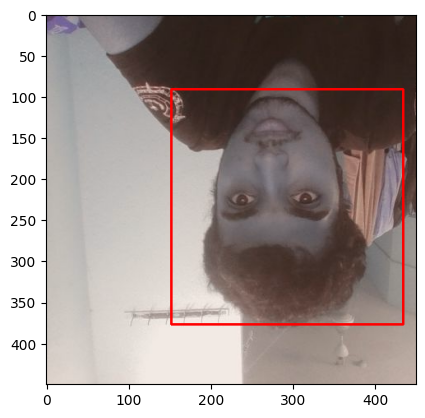

In [36]:
#drawing rectangle
cv2.rectangle(augmented['image'],
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)),
                    (255,0,0), 2)
plt.imshow(augmented['image'])


In [37]:
for partition in ['train', 'test', 'val']:
    os.makedirs(f'aug_data/{partition}/images', exist_ok=True)
    os.makedirs(f'aug_data/{partition}/labels', exist_ok=True)

In [38]:
for partition in ['train', 'test', 'val']:
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        coords = [0, 0, 0.00001, 0.00001]

        label_path = os.path.join(
            'data', partition, 'labels',
            f'{image.split(".")[0]}.json'
        )

        if os.path.exists(label_path):
            try:
                with open(label_path, 'r') as f:
                    label = json.load(f)

                # Check that annotation exists
                if len(label['shapes']) == 0:
                    print(f"Skipping empty annotation: {image}")
                    continue

                points = label['shapes'][0]['points']

                if len(points) < 2:
                    print(f"Skipping invalid annotation: {image}")
                    continue

                coords[0] = points[0][0]
                coords[1] = points[0][1]
                coords[2] = points[1][0]
                coords[3] = points[1][1]

                # Fix reversed bounding boxes
                coords[0], coords[2] = min(coords[0], coords[2]), max(coords[0], coords[2])
                coords[1], coords[3] = min(coords[1], coords[3]), max(coords[1], coords[3])

                # Normalize coordinates
                coords = list(np.divide(coords, [640, 480, 640, 480]))

            except Exception as e:
                print(f"Skipping {image}: {e}")
                continue

        try:
            for x in range(60):

                augmented = augmentor(
                    image=img,
                    bboxes=[coords],
                    class_labels=['face']
                )

                cv2.imwrite(
                    os.path.join(
                        'aug_data',
                        partition,
                        'images',
                        f'{image.split(".")[0]}.{x}.jpg'
                    ),
                    augmented['image']
                )

                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):

                    if len(augmented['bboxes']) == 0:
                        annotation['bbox'] = [0, 0, 0, 0]
                        annotation['class'] = 0

                    else:
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1

                else:
                    annotation['bbox'] = [0, 0, 0, 0]
                    annotation['class'] = 0

                with open(
                    os.path.join(
                        'aug_data',
                        partition,
                        'labels',
                        f'{image.split(".")[0]}.{x}.json'
                    ),
                    'w'
                ) as f:
                    json.dump(annotation, f)

        except Exception as e:
            print(f"Augmentation error for {image}: {e}")

Skipping empty annotation: 180a642e-ab8e-11f1-b33a-0242ac1c000c.jpg
Skipping empty annotation: 584b2d70-ab8e-11f1-b33a-0242ac1c000c.jpg


In [23]:
#This is done to train neural network
train_images = tf.data.Dataset.list_files(os.path.join('aug_data', 'train', 'images', '*jpg'), shuffle = False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120, 120)))
train_images = train_images.map(lambda x: x/255)


In [24]:
test_images = tf.data.Dataset.list_files(os.path.join('aug_data', 'test', 'images', '*jpg'), shuffle = False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120, 120)))
test_images = test_images.map(lambda x: x/255)

In [25]:
val_images = tf.data.Dataset.list_files(os.path.join('aug_data', 'val', 'images', '*jpg'), shuffle = False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120, 120)))
val_images = val_images.map(lambda x: x/255)

In [26]:
#Prepare labels
def load_labels(label_path):
  with open(label_path.numpy(), 'r', encoding ="utf-8") as f:
    label = json.load(f)

  return [label['class']], label['bbox']


In [66]:
train_labels = tf.data.Dataset.list_files('aug_data/train/labels/*.json', shuffle=False)
train_labels = train_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))
train_labels = train_labels.map(lambda cls, bbox: (tf.ensure_shape(cls, [1]), tf.ensure_shape(bbox, [4])))

In [67]:
test_labels = tf.data.Dataset.list_files('aug_data/test/labels/*.json', shuffle=False)
test_labels = test_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))
test_labels = test_labels.map(lambda cls, bbox: (tf.ensure_shape(cls, [1]), tf.ensure_shape(bbox, [4])))

In [68]:
val_labels = tf.data.Dataset.list_files('aug_data/val/labels/*.json', shuffle=False)
val_labels = val_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))
val_labels = val_labels.map(lambda cls, bbox: (tf.ensure_shape(cls, [1]), tf.ensure_shape(bbox, [4])))

In [69]:
len(val_images), len(val_labels)

(720, 720)

In [70]:
train_labels.as_numpy_iterator().next()

(array([1], dtype=uint8),
 array([0.097 , 0.1648, 0.723 , 0.8013], dtype=float16))

In [71]:
len(train_images), len(train_labels),len(test_images), len(test_labels),len(val_images), len(val_labels)

(3780, 3780, 780, 780, 720, 720)

In [72]:
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

In [73]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

In [74]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

In [75]:
train.as_numpy_iterator().next()[0].shape #8 images 120x120 wide 3 colours rgb

(8, 120, 120, 3)

In [76]:
train.as_numpy_iterator().next()[1]

(array([[0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.     , 0.     , 0.     , 0.     ],
        [0.3958 , 0.2727 , 0.6885 , 0.6665 ],
        [0.6924 , 0.435  , 0.9756 , 0.7886 ],
        [0.     , 0.397  , 0.198  , 0.8716 ],
        [0.2255 , 0.1508 , 0.8013 , 0.8677 ],
        [0.1589 , 0.2    , 0.462  , 0.5938 ],
        [0.2295 , 0.05597, 0.795  , 0.6724 ],
        [0.689  , 0.3523 , 1.     , 0.817  ]], dtype=float16))

In [77]:
data_samples = train.as_numpy_iterator() #numpy iteratr allows to loop through batches


In [78]:
res = data_samples.next()

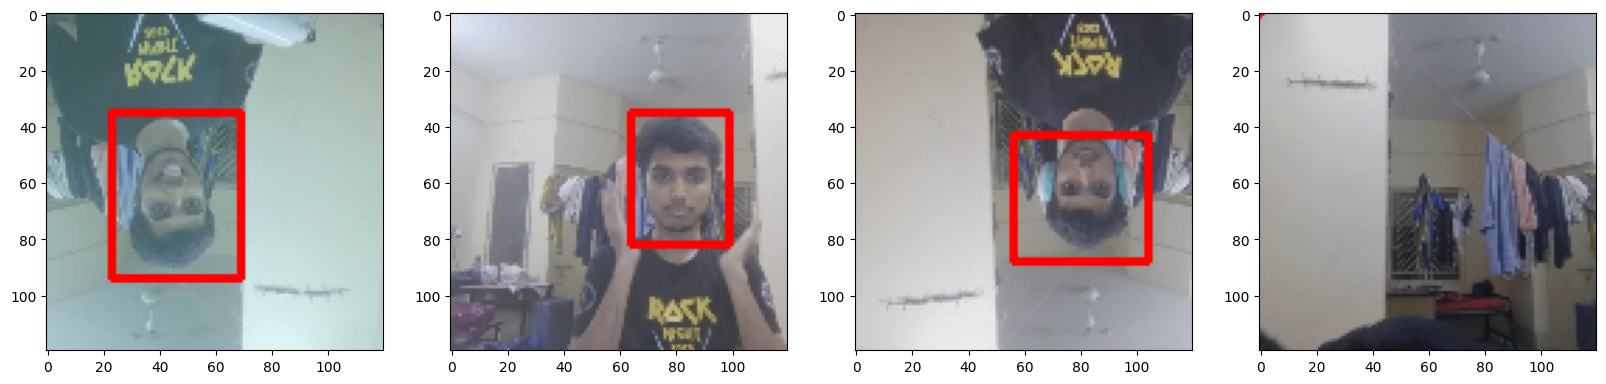

In [79]:
#Visualising aumentated data
fig, ax = plt.subplots(ncols=4, figsize=(20,20))

for idx in range(4):
    sample_image = res[0][idx].copy()
    sample_coords = res[1][1][idx]

    cv2.rectangle(
        sample_image,
        tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
        tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
        (255,0,0),
        2
    )

    ax[idx].imshow(sample_image)

Building and Training Model


In [80]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Add, GlobalMaxPooling2D
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16

In [81]:
vgg = VGG16(include_top =False)

In [82]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
def build_model():
  input_layer = layers.Input(shape=(120,120,3))

  vgg = VGG16(include_top=False)(input_layer)

  f1 = GlobalMaxPooling2D()(vgg)
  class1 = Dense(2048, activation='relu')(f1)
  class2 = Dense(1, activation='sigmoid')(class1)

  f2= GlobalMaxPooling2D()(vgg)
  regress1 = Dense(2048, activation = 'relu')(f2)
  regress2 = Dense(4, activation='sigmoid')(regress1)

  facetracker = Model(inputs = input_layer, outputs=[class2, regress2])
  return facetracker

In [84]:
train.as_numpy_iterator().next()[1]

(array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.3796 , 0.3425 , 0.6875 , 0.6714 ],
        [0.     , 0.4758 , 0.1866 , 0.9907 ],
        [0.243  , 0.2119 , 0.748  , 0.8784 ],
        [0.3022 , 0.2045 , 0.858  , 0.8003 ],
        [0.478  , 0.2422 , 0.7812 , 0.636  ],
        [0.1504 , 0.32   , 0.5576 , 0.656  ],
        [0.     , 0.3186 , 0.06082, 0.8047 ],
        [0.3608 , 0.1081 , 0.8657 , 0.775  ]], dtype=float16))

In [85]:
facetracker = build_model()

In [86]:
facetracker.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2048)      │  1,050,624 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 2048)      │  1,050,624 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │      2,049 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │      8,196 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,826,181 (64.19 MB)

 Trainable params: 16,826,181 (64.19 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
X, y = train.as_numpy_iterator().next()

In [88]:
X.shape

(8, 120, 120, 3)

In [89]:
y

(array([[1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.676  , 0.1675 , 1.     , 0.6323 ],
        [0.     , 0.     , 0.     , 0.     ],
        [0.5444 , 0.3896 , 0.8574 , 0.7026 ],
        [0.0095 , 0.10645, 0.555  , 0.6724 ],
        [0.     , 0.04465, 0.2866 , 0.5596 ],
        [0.3035 , 0.2861 , 0.667  , 0.7104 ],
        [0.8438 , 0.3364 , 1.     , 0.8223 ],
        [0.     , 0.2257 , 0.2793 , 0.8115 ]], dtype=float16))

In [90]:
batches_per_epoch = 690
lr_decay = (1./0.75 - 1)/batches_per_epoch

In [91]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0001, decay=lr_decay)

In [92]:
lr_decay

0.0004830917874396134

In [93]:
#get distance between actual and predicted coordinates
def localization_loss(y_true, yhat):
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))

    h_true = y_true[:,3] - y_true[:,1]
    w_true = y_true[:,2] - y_true[:,0]

    h_pred = yhat[:,3] - yhat[:,1]
    w_pred = yhat[:,2] - yhat[:,0]

    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true-h_pred))

    return delta_coord + delta_size

In [94]:
classes, coords = facetracker(X)

In [95]:
localization_loss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=3.020702838897705>

In [96]:
classloss = tf.keras.losses.BinaryCrossentropy()
regressloss = localization_loss

In [97]:
classloss(y[0], classes).numpy()

np.float32(0.7172275)

In [98]:
regressloss(y[1], coords).numpy()

np.float32(3.0207028)

Train Neural Network


In [99]:
class FaceTracker(Model):
    def __init__(self, eyetracker,  **kwargs):
        super().__init__(**kwargs)
        self.model = eyetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt

    def train_step(self, batch, **kwargs):

        X, y = batch

        with tf.GradientTape() as tape:
            classes, coords = self.model(X, training=True)

            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)

            total_loss = batch_localizationloss+0.5*batch_classloss

            grad = tape.gradient(total_loss, self.model.trainable_variables)

        opt.apply_gradients(zip(grad, self.model.trainable_variables))

        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}

    def test_step(self, batch, **kwargs):
        X, y = batch

        classes, coords = self.model(X, training=False)

        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss

        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}

    def call(self, X, **kwargs):
        return self.model(X, **kwargs)

In [100]:
model = FaceTracker(facetracker)

In [101]:
model.compile(opt,classloss,regressloss)

In [102]:
logdir = 'logs'

In [103]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [104]:
hist = model.fit(train, epochs=10, validation_data =val,
                 callbacks = [tensorboard_callback])

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 74s 108ms/step - class_loss: 0.0164 - regress_loss: 0.1584 - total_loss: 0.1667 - val_class_loss: 0.0205 - val_regress_loss: 0.1449 - val_total_loss: 0.1552
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 46s 83ms/step - class_loss: 5.1058e-04 - regress_loss: 0.0047 - total_loss: 0.0049 - val_class_loss: 0.0045 - val_regress_loss: 0.2144 - val_total_loss: 0.2166
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 48s 84ms/step - class_loss: 6.0614e-05 - regress_loss: 0.0127 - total_loss: 0.0128 - val_class_loss: 0.4674 - val_regress_loss: 0.1609 - val_total_loss: 0.3946
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 51s 87ms/step - class_loss: 5.4604e-04 - regress_loss: 0.0206 - total_loss: 0.0209 - val_class_loss: 0.0072 - val_regress_loss: 0.1874 - val_total_loss: 0.1911
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 47s 85ms/step - class_loss: 3.6521e-04 - regress_loss: 0.0065 - total_loss: 0.0066 - val_class_loss: 2.9275e-05 - val_regress_loss: 0.1122 - val_total_loss: 0.1122

In [105]:
hist.history

{'class_loss': [0.01643572747707367,
  0.000510584912262857,
  6.061437670723535e-05,
  0.0005460415850393474,
  0.0003652074665296823,
  1.8061931541524245e-06,
  0.00021077961719129235,
  0.001732859993353486,
  0.00011447403812780976,
  6.993010174483061e-05],
 'regress_loss': [0.15844571590423584,
  0.0046572620049119,
  0.012749039568006992,
  0.020640937611460686,
  0.006451725028455257,
  0.004968860652297735,
  0.00800988357514143,
  0.014237958006560802,
  0.0034617739729583263,
  0.005090918391942978],
 'total_loss': [0.16666358709335327,
  0.004912554286420345,
  0.01277934666723013,
  0.02091395854949951,
  0.006634328979998827,
  0.004969763569533825,
  0.008115272969007492,
  0.015104387886822224,
  0.0035190109629184008,
  0.005125883501023054],
 'val_class_loss': [0.02054811641573906,
  0.004501495976001024,
  0.46736833453178406,
  0.007221563719213009,
  2.927490641013719e-05,
  0.00012580209295265377,
  0.000631609233096242,
  0.07540464401245117,
  0.000232225909712

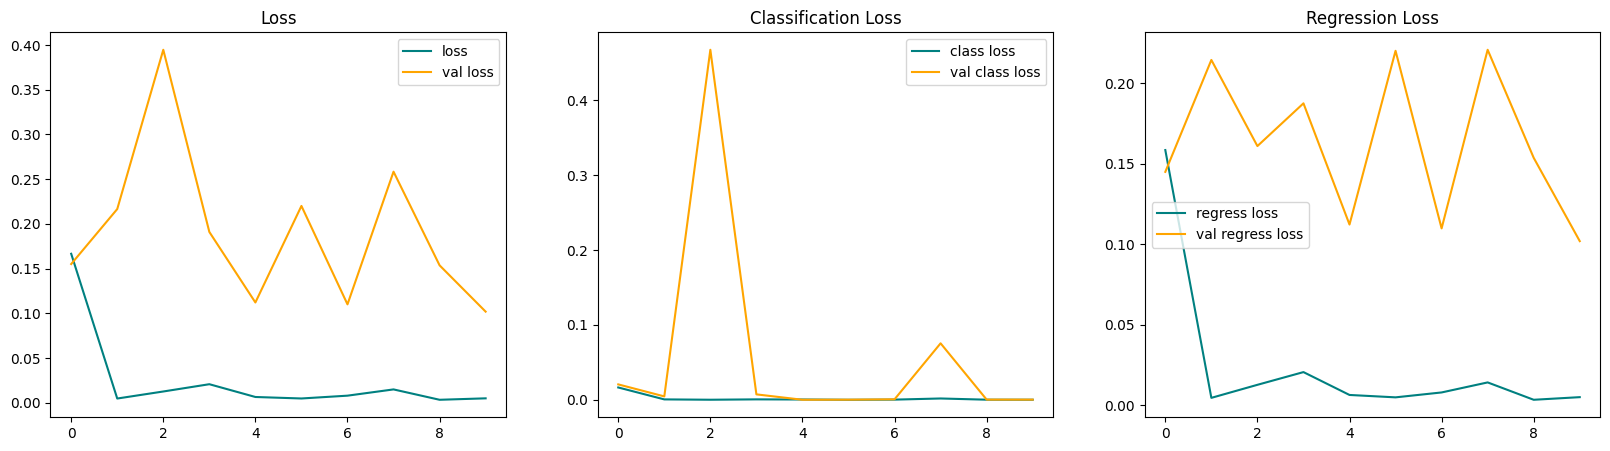

In [157]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

In [182]:
test_data = test.as_numpy_iterator()

In [159]:
test_sample = test_data.next()

In [160]:
yhat = facetracker.predict(test_sample[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step


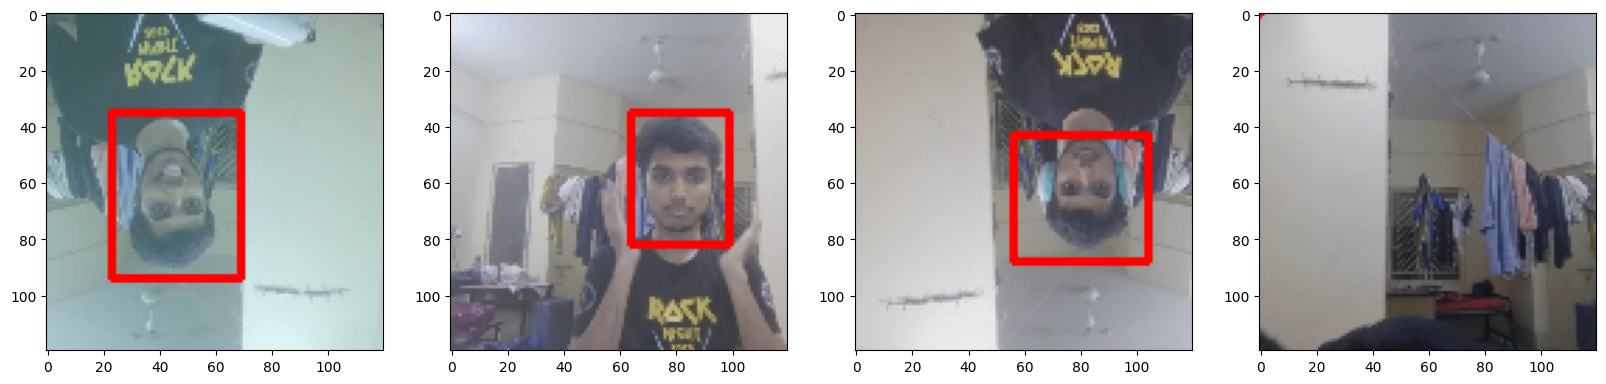

In [161]:
# Visualising augmented data
fig, ax = plt.subplots(ncols=4, figsize=(20,20))

for idx in range(4):
    sample_image = res[0][idx].copy()
    sample_coords = res[1][1][idx]

    cv2.rectangle(
        sample_image,
        tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
        tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
        (255,0,0),
        2
    )

    ax[idx].imshow(sample_image)

In [193]:
from tensorflow.keras.models import load_model

In [150]:
facetracker.save('facetracker.h5')

In [142]:
facetracker = load_model('facetracker.h5')

In [146]:
from google.colab import files
files.download('facetracker.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Real-Time Face Detection

from google.colab.output import eval_js
from IPython.display import display, Javascript
import base64
import numpy as np
import cv2
import tensorflow as tf
import time

display(Javascript("""
(async () => {

    const old = document.getElementById("camera");
    if (old) old.remove();

    const container = document.createElement("div");
    container.id = "camera";
    container.style.position = "relative";
    container.style.width = "640px";

    const video = document.createElement("video");
    video.autoplay = true;
    video.playsInline = true;
    video.style.width = "640px";

    const canvas = document.createElement("canvas");
    canvas.style.position = "absolute";
    canvas.style.left = "0";
    canvas.style.top = "0";
    canvas.style.width = "640px";
    canvas.style.height = "480px";
    canvas.style.pointerEvents = "none";

    const button = document.createElement("button");
    button.innerText = "Stop Camera";

    container.appendChild(video);
    container.appendChild(canvas);
    container.appendChild(button);
    document.body.appendChild(container);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: true,
        audio: false
    });

    video.srcObject = stream;
    await video.play();

    canvas.width = video.videoWidth;
    canvas.height = video.videoHeight;

    window.video = video;
    window.canvas = canvas;
    window.stream = stream;
    window.running = true;

    button.onclick = () => {
        window.running = false;
        stream.getTracks().forEach(track => track.stop());
    };

    window.getFrame = () => {

        const temp = document.createElement("canvas");

        temp.width = video.videoWidth;
        temp.height = video.videoHeight;

        const ctx = temp.getContext("2d");
        ctx.drawImage(video, 0, 0);

        return temp.toDataURL("image/jpeg");
    };

    window.drawBox = (x1, y1, x2, y2) => {

        const ctx = canvas.getContext("2d");

        ctx.clearRect(0, 0, canvas.width, canvas.height);

        ctx.strokeStyle = "red";
        ctx.lineWidth = 4;

        ctx.strokeRect(
            x1 * canvas.width,
            y1 * canvas.height,
            (x2 - x1) * canvas.width,
            (y2 - y1) * canvas.height
        );
    };

    window.clearBox = () => {

        const ctx = canvas.getContext("2d");

        ctx.clearRect(
            0, 0,
            canvas.width,
            canvas.height
        );
    };

})();
"""))

time.sleep(2)

while True:

    if not eval_js("window.running"):
        break

    # Get webcam frame
    data = eval_js("window.getFrame()")

    image = base64.b64decode(data.split(",")[1])

    frame = cv2.imdecode(
        np.frombuffer(image, np.uint8),
        cv2.IMREAD_COLOR
    )

    height, width = frame.shape[:2]

    # Crop to square
    size = min(height, width)

    start_x = (width - size) // 2
    start_y = (height - size) // 2

    crop = frame[
        start_y:start_y + size,
        start_x:start_x + size
    ]

    # Prepare image
    rgb = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    resized = tf.image.resize(
        rgb,
        (120, 120)
    )

    input_image = np.expand_dims(
        resized.numpy() / 255.0,
        axis=0
    )

    # Predict using your trained model
    yhat = facetracker.predict(
        input_image,
        verbose=0
    )

    confidence = float(yhat[0][0][0])
    coords = yhat[1][0]

    # Draw bounding box
    if confidence > 0.50:

        x1, y1, x2, y2 = coords

        x1 = (start_x + x1 * size) / width
        y1 = (start_y + y1 * size) / height

        x2 = (start_x + x2 * size) / width
        y2 = (start_y + y2 * size) / height

        eval_js(
            f"window.drawBox({x1}, {y1}, {x2}, {y2})"
        )

    else:

        eval_js("window.clearBox()")

    time.sleep(0.05)

print("Camera stopped.")

<IPython.core.display.Javascript object>